### EBA detects structural in absence of clear sequence identity

In [1]:
import pickle
import os
import scipy.stats
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
viridis = cm.get_cmap('viridis', 256)

In [2]:
working_dir = '.'
results_path = os.path.join(working_dir, 'results')
data_dir = os.path.join(working_dir,'data')
sequence_file = os.path.join(data_dir, 'sequences.fasta')
tm_scores_path = os.path.join(results_path, 'TM_scores.pickle')

Load PISCES pairs TM-scores 

In [3]:
with open(tm_scores_path, 'rb') as handle:
    all_tm_scores = pickle.load(handle)
    
print('{} TM scores loaded'.format(len(all_tm_scores)))

40932 TM scores loaded


Remove reduntant pairs ( TM(a,b)=TM(b,a) )

In [4]:
tm_scores = dict()
for p in all_tm_scores:
    if (p[1],p[0]) not in tm_scores.keys():
        tm_scores[p]=all_tm_scores[p]
        
print('{} TM scores filtred'.format(len(tm_scores)))

20466 TM scores filtred


Load sequences

In [5]:
sequences = dict()
with open(sequence_file, 'r') as file:
    for line in file:
        if line[0]=='>':
            pdb_id = line.split()[0][1:]
            sequences[pdb_id] = ''
        else:
            sequences[pdb_id]+=line.strip()

seq_length = {seq_id:len(sequences[seq_id])for seq_id in sequences}

Load predictions

In [13]:
results = dict()
for scores in os.listdir(results_path):
    if scores.split('_')[0]=='TM':
        continue
    score_file = os.path.join(results_path, scores)
    with open(score_file, 'rb') as handle:
        print('loading: {}'.format(scores))
        results[scores.split('.')[0]] = pickle.load(handle)

loading: ProtT5_AD.pickle
loading: ESMb1_EBA.pickle
loading: ESMb1_AD.pickle
loading: ProtT5_EBA.pickle


### Define sorting functions

In [15]:
def sort_EBA_results(model, tm_scores):
    ordered_results = {'min':list(), 'max':list(), 'raw':list()}
    gt_ordered = {'tm_min':list(), 'tm_max':list(), 'r':list()}
    
    for p in results['{}_EBA'.format(model)]:
        short = min(seq_length[p[0]],seq_length[p[1]])
        long = max(seq_length[p[0]],seq_length[p[1]])
        
        #skip short sequences
        if short<75:
            continue
        
        if p in tm_scores.keys():
            gt_ordered['tm_min'].append(min(tm_scores[p]['TM1'], tm_scores[p]['TM2']))
            gt_ordered['tm_max'].append(max(tm_scores[p]['TM1'], tm_scores[p]['TM2']))
            gt_ordered['r'].append(short/long)
            
            ordered_results['min'].append(results['{}_EBA'.format(model)][p]['EBA_min'])
            ordered_results['max'].append(results['{}_EBA'.format(model)][p]['EBA_max'])
            ordered_results['raw'].append(results['{}_EBA'.format(model)][p]['EBA_raw'])
            
        else:
            continue
            
    return ordered_results,gt_ordered

In [16]:
def sort_AD_results(model, tm_scores):
    ordered_results = list()
    gt_ordered = {'tm_min':list(), 'tm_max':list(), 'r':list()}
    
    for p in results['{}_AD'.format(model)]:
        short = min(seq_length[p[0]],seq_length[p[1]])
        long = max(seq_length[p[0]],seq_length[p[1]])
        
        #skip short sequences
        if short<75:
            continue
        
        if p in tm_scores.keys():
            gt_ordered['tm_min'].append(min(tm_scores[p]['TM1'], tm_scores[p]['TM2']))
            gt_ordered['tm_max'].append(max(tm_scores[p]['TM1'], tm_scores[p]['TM2']))
            gt_ordered['r'].append(short/long)
            
            ordered_results.append(results['{}_AD'.format(model)][p].item())
            
        else:
            continue
            
    return ordered_results,gt_ordered

## Sort results

In [17]:
ESMb1_EBA_results, ESMb1_EBA_gt = sort_EBA_results('ESMb1', tm_scores)
ProtT5_EBA_results, ProtT5_EBA_gt = sort_EBA_results('ProtT5', tm_scores)

In [18]:
ESMb1_AD_results, ESMb1_AD_gt = sort_AD_results('ESMb1', tm_scores)
ProtT5_AD_results, ProtT5_AD_gt = sort_AD_results('ProtT5', tm_scores)

### ESM-b1 Spearman correlation

In [19]:
print('EBA\n')
print('tm_min:', scipy.stats.spearmanr(ESMb1_EBA_results['min'], ESMb1_EBA_gt['tm_min']))
print('tm_max:', scipy.stats.spearmanr(ESMb1_EBA_results['max'], ESMb1_EBA_gt['tm_max']))

EBA

tm_min: SpearmanrResult(correlation=0.7317035905271199, pvalue=8.80164237029888e-07)
tm_max: SpearmanrResult(correlation=0.5468296409472879, pvalue=0.000818869525580086)


In [20]:
print('AD\n')
print('tm_min:', scipy.stats.spearmanr(ESMb1_AD_results, ESMb1_AD_gt['tm_min']))
print('tm_max:', scipy.stats.spearmanr(ESMb1_AD_results, ESMb1_AD_gt['tm_max']))

AD

tm_min: SpearmanrResult(correlation=-0.36562261268143614, pvalue=0.03346752830498633)
tm_max: SpearmanrResult(correlation=-0.23941940412528645, pvalue=0.17264455127018866)


### ProtT5 Spearman correlations

In [21]:
print('EBA\n')
print('tm_min:', scipy.stats.spearmanr(ProtT5_EBA_results['min'], ProtT5_EBA_gt['tm_min']))
print('tm_max:', scipy.stats.spearmanr(ProtT5_EBA_results['max'], ProtT5_EBA_gt['tm_max']))

EBA

tm_min: SpearmanrResult(correlation=0.6947288006111534, pvalue=5.15148487734179e-06)
tm_max: SpearmanrResult(correlation=0.45271199388846445, pvalue=0.007179277039895021)


In [22]:
print('AD\n')
print('tm_min:', scipy.stats.spearmanr(ProtT5_AD_results, ProtT5_AD_gt['tm_min']))
print('tm_max:', scipy.stats.spearmanr(ProtT5_AD_results, ProtT5_AD_gt['tm_max']))

AD

tm_min: SpearmanrResult(correlation=-0.28220015278838806, pvalue=0.1058770329821583)
tm_max: SpearmanrResult(correlation=-0.21925133689839568, pvalue=0.21281929247451958)


### Plot example: ProtT5

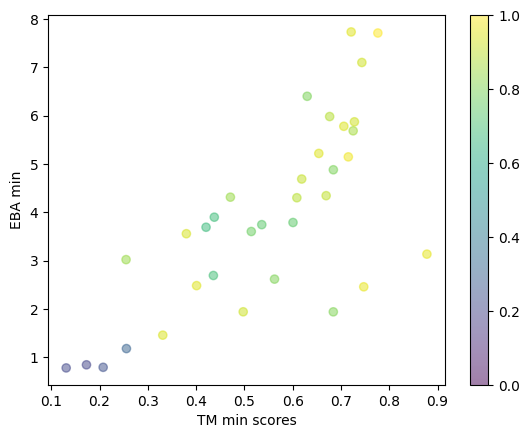

In [23]:
colors = ProtT5_EBA_gt['r']
plt.xlabel('TM min scores')
plt.ylabel('EBA min')
plt.scatter(ProtT5_EBA_gt['tm_min'], 
            ProtT5_EBA_results['min'],
            alpha=0.5,
            c=colors,
            cmap= viridis,
            vmin=0, vmax=1)
plt.colorbar()